# Análise de Métricas de Qualidade — Código Java com Contribuição do Claude

Dataset real extraído com a ferramenta **CK** (Chidamber & Kemerer 1994) + bugs do **SpotBugs**.
Unidade de análise = a **classe**. Métricas OO genuínas (DIT, CBO, RFC, LCOM, LCOM\* etc.),
diferente da versão anterior baseada em proxies.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
sns.set_style('whitegrid'); ALPHA = 0.05

Matplotlib is building the font cache; this may take a moment.


## 1. Carregamento e pré-processamento

In [2]:
df_raw = pd.read_csv('../data/dataset.csv')
print('Shape:', df_raw.shape)
print('Repos:', df_raw['repo'].nunique())
df_raw.head()

Shape: (11459, 16)
Repos: 10


,file,class,LOC,WMC,CBO,RFC,DIT,NOC,LCOM,LCOM_norm,NM,NPM,McCC_avg,McCC_max,Number_of_bugs,repo
0,/app/data/raw/apache__flink-agents/runtime/src...,OperatorUtils,4,1,1,0,1,0,0,0.0,1,1,1.0,1.0,NaN,apache/flink-agents
1,/app/data/raw/apache__flink-agents/integration...,org.apache.flink.agents.integrations.chatmodel...,304,90,28,112,2,0,83,0.8,15,3,6.0,17.0,NaN,apache/flink-agents
2,/app/data/raw/apache__flink-agents/integration...,org.apache.flink.agents.integrations.chatmodel...,19,3,6,9,1,0,0,0.0,3,0,1.0,1.0,NaN,apache/flink-agents
3,/app/data/raw/apache__flink-agents/plan/src/te...,org.apache.flink.agents.plan.tools.SchemaUtils...,8,3,1,0,1,0,3,0.0,3,3,1.0,1.0,NaN,apache/flink-agents
4,/app/data/raw/apache__flink-agents/api/src/mai...,org.apache.flink.agents.api.context.MemoryObject,15,10,2,1,1,0,45,0.0,10,0,1.0,1.0,NaN,apache/flink-agents


In [3]:
# Métricas OO reais do CK (sem colunas de identificação nem a resposta).
METRICAS = ['LOC','WMC','CBO','RFC','DIT','NOC','LCOM','LCOM_norm','NM','NPM','McCC_avg','McCC_max']
METRICAS = [c for c in METRICAS if c in df_raw.columns]
# df_m: base de métricas (todas as classes); McCC pode faltar p/ classe sem método.
df = df_raw.copy()
print('Classes:', len(df), '| Métricas:', len(METRICAS))

Classes: 11459 | Métricas: 12


## 2. Estatística descritiva

In [4]:
desc = df[METRICAS].describe(percentiles=[.25,.5,.75,.90,.95]).T
desc.round(2)

,count,mean,std,min,25%,50%,75%,90%,95%,max
LOC,11459.0,70.61,141.95,1.0,28.00,49.00,79.00,127.20,181.00,7445.0
WMC,11459.0,12.00,27.45,0.0,6.00,8.00,13.00,21.00,29.00,1830.0
CBO,11459.0,5.74,9.37,0.0,4.00,5.00,6.00,9.00,12.00,418.0
RFC,11459.0,7.23,21.78,0.0,1.00,2.00,7.00,18.20,31.00,1525.0
DIT,11459.0,1.37,1.02,1.0,1.00,1.00,2.00,2.00,2.00,74.0
NOC,11459.0,0.28,17.46,0.0,0.00,0.00,0.00,0.00,0.00,1436.0
LCOM,11459.0,152.60,3633.65,0.0,0.00,10.00,23.00,68.00,144.00,327645.0
LCOM_norm,11384.0,0.49,0.34,0.0,0.03,0.57,0.77,0.87,0.91,1.0
NM,11459.0,10.01,18.60,0.0,5.00,8.00,11.00,17.00,22.10,810.0
NPM,11459.0,8.38,17.52,0.0,3.00,6.00,10.00,16.00,21.00,810.0


## 3. Distribuição e normalidade (Kolmogorov–Smirnov)
H0: distribuição normal. Esperamos rejeitar (dados de software são assimétricos).

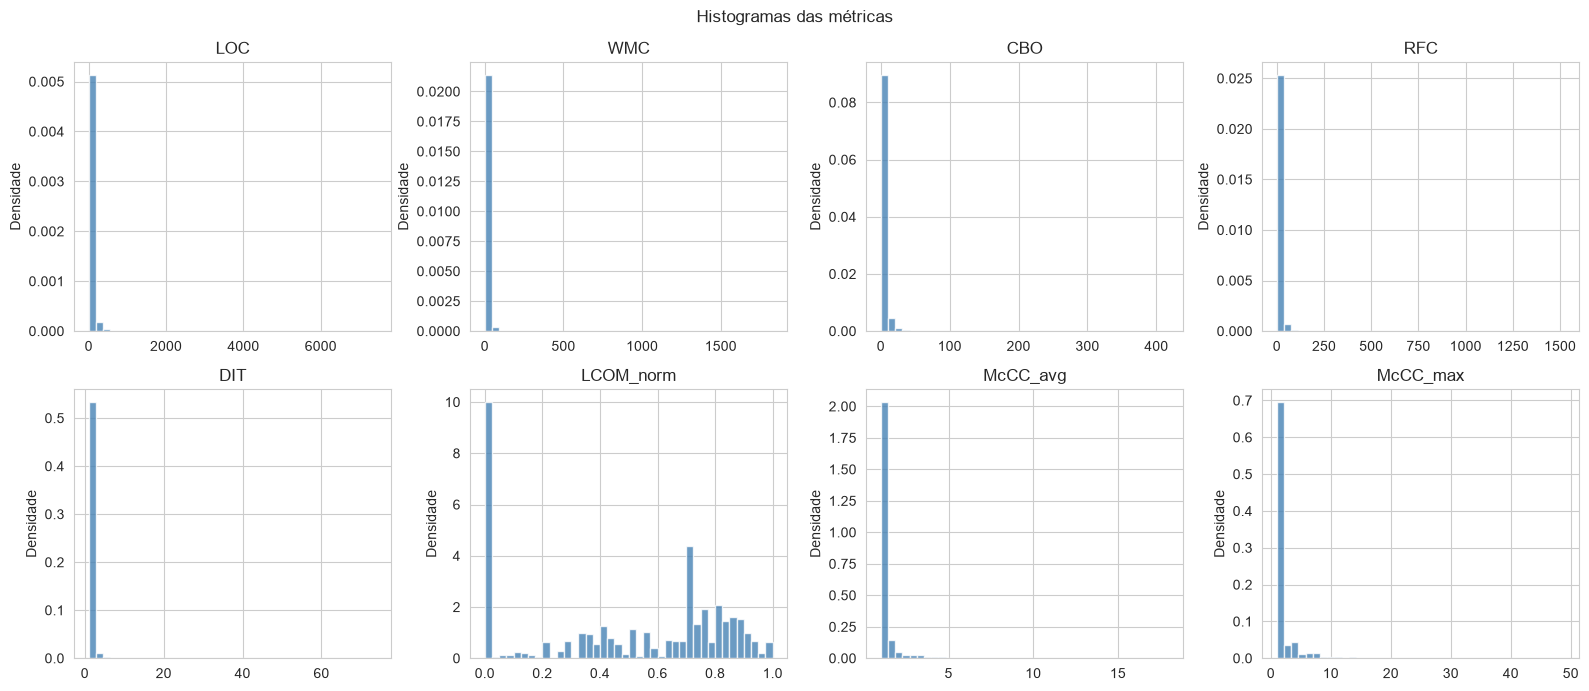

In [5]:
PLOT = [c for c in ['LOC','WMC','CBO','RFC','DIT','LCOM_norm','McCC_avg','McCC_max'] if c in df.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.flatten()
for i, col in enumerate(PLOT):
    d = df[col].dropna()
    axes[i].hist(d, bins=40, color='steelblue', alpha=0.8, density=True, edgecolor='white')
    axes[i].set_title(col); axes[i].set_ylabel('Densidade')
for j in range(len(PLOT), len(axes)): axes[j].set_visible(False)
plt.suptitle('Histogramas das métricas'); plt.tight_layout()
plt.savefig('normalidade.png', bbox_inches='tight'); plt.show()

In [6]:
ks = []
for col in METRICAS:
    d = df[col].dropna()
    stat, pval = stats.kstest(d, 'norm', args=(d.mean(), d.std()))
    ks.append({'Variável': col, 'D': round(stat,4), 'p': f'{pval:.1e}',
               'Normal?': 'Não' if pval < ALPHA else 'Sim'})
pd.DataFrame(ks).set_index('Variável')

,D,p,Normal?
Variável,,,
LOC,0.3119,0.0e+00,Não
WMC,0.3310,0.0e+00,Não
CBO,0.3084,0.0e+00,Não
RFC,0.3700,0.0e+00,Não
DIT,0.3569,0.0e+00,Não
NOC,0.5005,0.0e+00,Não
LCOM,0.4833,0.0e+00,Não
LCOM_norm,0.1805,0.0e+00,Não
NM,0.2952,0.0e+00,Não


## 4. Outliers (critério IQR)

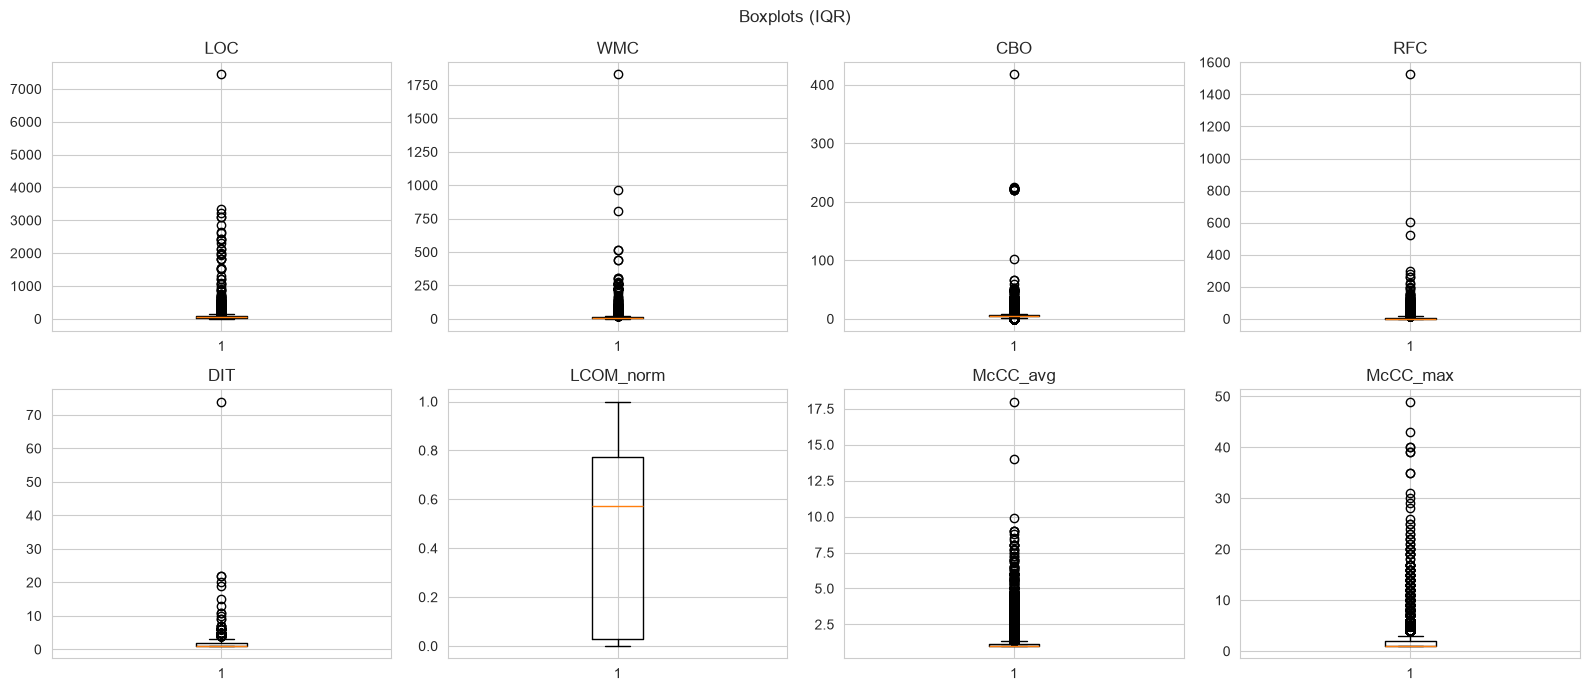

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.flatten()
for i, col in enumerate(PLOT):
    axes[i].boxplot(df[col].dropna(), vert=True); axes[i].set_title(col)
for j in range(len(PLOT), len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplots (IQR)'); plt.tight_layout()
plt.savefig('boxplot.png', bbox_inches='tight'); plt.show()

## 5. Code smells por threshold (literatura CK / Fowler 1999)

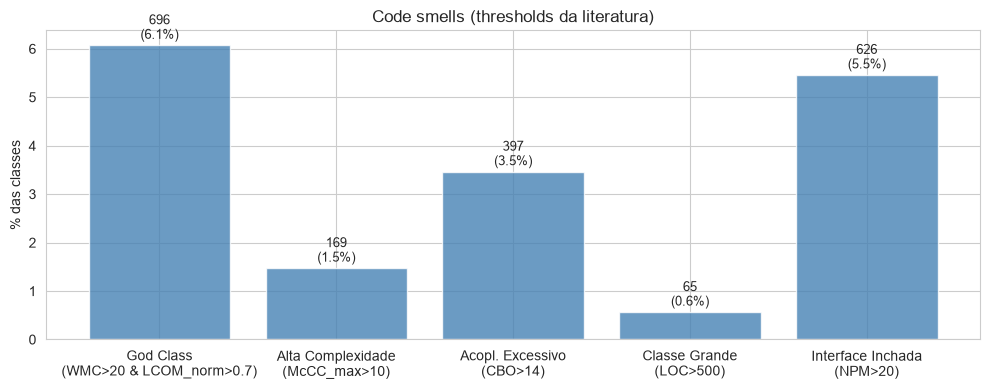

{'God Class\n(WMC>20 & LCOM_norm>0.7)': np.int64(696),
 'Alta Complexidade\n(McCC_max>10)': np.int64(169),
 'Acopl. Excessivo\n(CBO>14)': np.int64(397),
 'Classe Grande\n(LOC>500)': np.int64(65),
 'Interface Inchada\n(NPM>20)': np.int64(626)}

In [8]:
smells = {
    'God Class\n(WMC>20 & LCOM_norm>0.7)': ((df['WMC']>20) & (df['LCOM_norm']>0.7)).sum(),
    'Alta Complexidade\n(McCC_max>10)':      (df['McCC_max']>10).sum(),
    'Acopl. Excessivo\n(CBO>14)':            (df['CBO']>14).sum(),
    'Classe Grande\n(LOC>500)':              (df['LOC']>500).sum(),
    'Interface Inchada\n(NPM>20)':           (df['NPM']>20).sum(),
}
fig, ax = plt.subplots(figsize=(10,4))
vals = list(smells.values()); pcts = [v/len(df)*100 for v in vals]
bars = ax.bar(list(smells.keys()), pcts, color='steelblue', alpha=0.8, edgecolor='white')
for b,v,p in zip(bars, vals, pcts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{v}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% das classes'); ax.set_title('Code smells (thresholds da literatura)')
plt.tight_layout(); plt.savefig('code_smells.png', bbox_inches='tight'); plt.show()
smells

## 6. Complexidade ciclomática (McCC) — McCabe 1976
McCC_avg/McCC_max são distintos do WMC (soma).

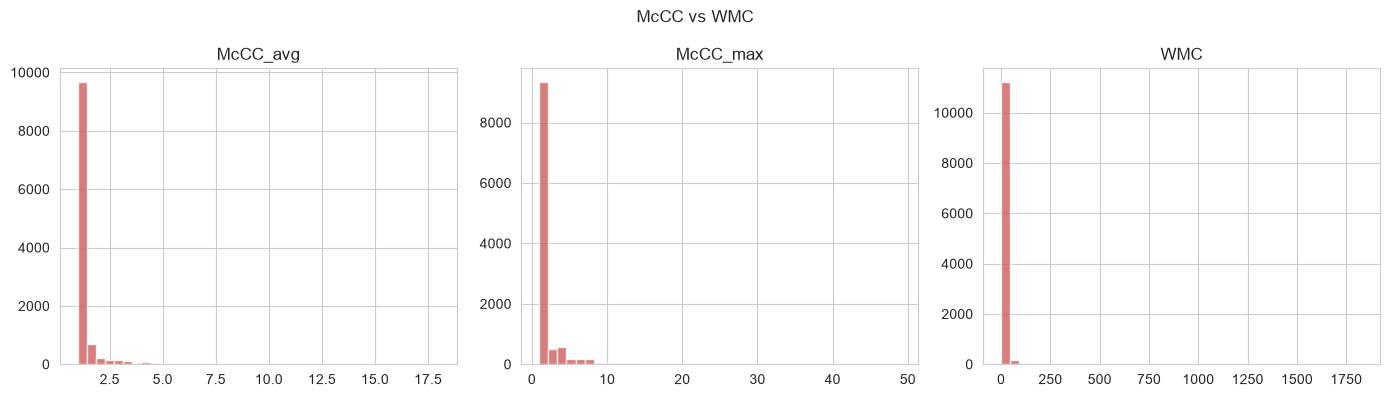

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['McCC_avg','McCC_max','WMC']):
    axes_d = df[col].dropna()
    ax.hist(axes_d, bins=40, color='indianred', alpha=0.8, edgecolor='white'); ax.set_title(col)
plt.suptitle('McCC vs WMC'); plt.tight_layout()
plt.savefig('mccc.png', bbox_inches='tight'); plt.show()

## 7. Correlação de Spearman entre métricas
Spearman (não paramétrico) porque os dados não são normais (seção 3).

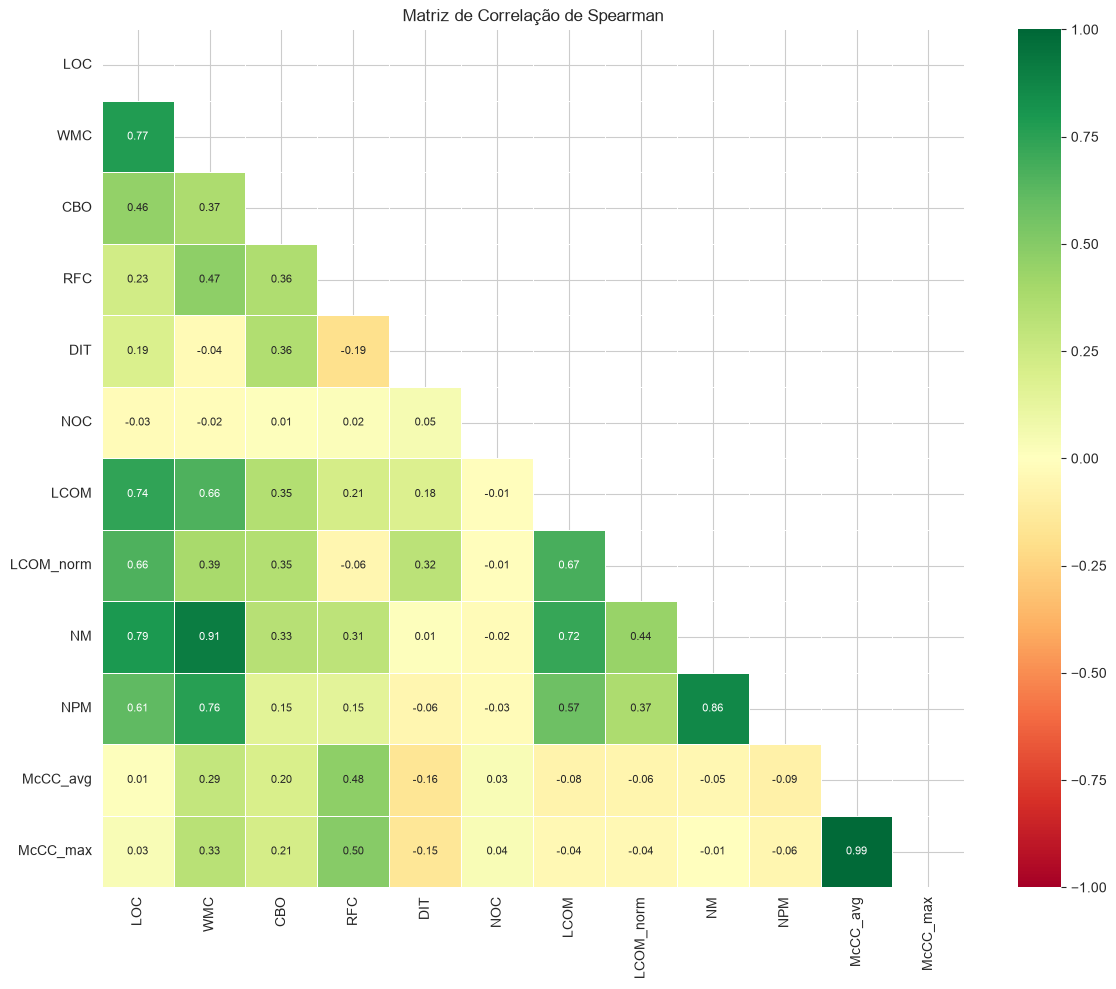

In [10]:
corr = df[METRICAS].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':8}, linewidths=0.5)
ax.set_title('Matriz de Correlação de Spearman'); plt.tight_layout()
plt.savefig('correlacao.png', bbox_inches='tight'); plt.show()

## 8. **Bugs vs. métricas — a questão de pesquisa central**
Métricas OO predizem defeitos? (Subramanyam & Krishnan 2003; Basili 1996.)
Usamos **só as classes de repos que compilaram** (Number_of_bugs não-NaN);
classes não analisadas (build falhou) são NaN e ficam de fora.

In [11]:
built = df[df['Number_of_bugs'].notna()].copy()
print(f'Classes com dado de bug: {len(built)} de {built["repo"].nunique()} repos')
print(f'Classes com >=1 bug: {(built.Number_of_bugs>0).sum()} | total de bugs: {int(built.Number_of_bugs.sum())}')
built['Number_of_bugs'].describe()

Classes com dado de bug: 1771 de 6 repos
Classes com >=1 bug: 174 | total de bugs: 527


count    1771.000000
mean        0.297572
std         1.661831
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        48.000000
Name: Number_of_bugs, dtype: float64

In [12]:
# Spearman de cada métrica vs Number_of_bugs
rows = []
for m in METRICAS:
    sub = built[[m,'Number_of_bugs']].dropna()
    rho, p = stats.spearmanr(sub[m], sub['Number_of_bugs'])
    rows.append({'Métrica': m, 'rho': round(rho,3), 'p': f'{p:.1e}',
                 'sig': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'})
bug_corr = pd.DataFrame(rows).sort_values('rho', key=lambda s: s.abs(), ascending=False).set_index('Métrica')
bug_corr

,rho,p,sig
Métrica,,,
NPM,0.308,4.2e-40,***
LCOM_norm,0.307,1.6e-39,***
WMC,0.281,2.2e-33,***
LOC,0.265,7.8e-30,***
McCC_max,0.241,7.3e-23,***
NM,0.235,1.2e-23,***
McCC_avg,0.214,3.7e-18,***
LCOM,0.211,2.6e-19,***
CBO,0.200,1.8e-17,***


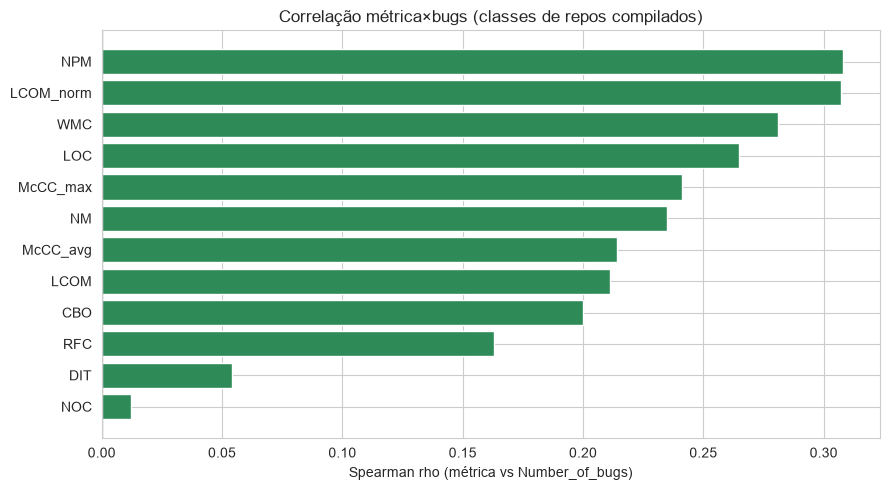

In [13]:
fig, ax = plt.subplots(figsize=(9,5))
bc = bug_corr.copy(); bc['rho'] = bc['rho'].astype(float)
bc = bc.sort_values('rho')
ax.barh(bc.index, bc['rho'], color=['seagreen' if x>0 else 'indianred' for x in bc['rho']])
ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('Spearman rho (métrica vs Number_of_bugs)')
ax.set_title('Correlação métrica×bugs (classes de repos compilados)')
plt.tight_layout(); plt.savefig('bugs_correlacao.png', bbox_inches='tight'); plt.show()

## 9. PCA + Cluster (K-Means)

  PC1: 41.1% (acum 41.1%)
  PC2: 17.0% (acum 58.2%)
  PC3: 9.5% (acum 67.7%)
  PC4: 8.3% (acum 76.0%)


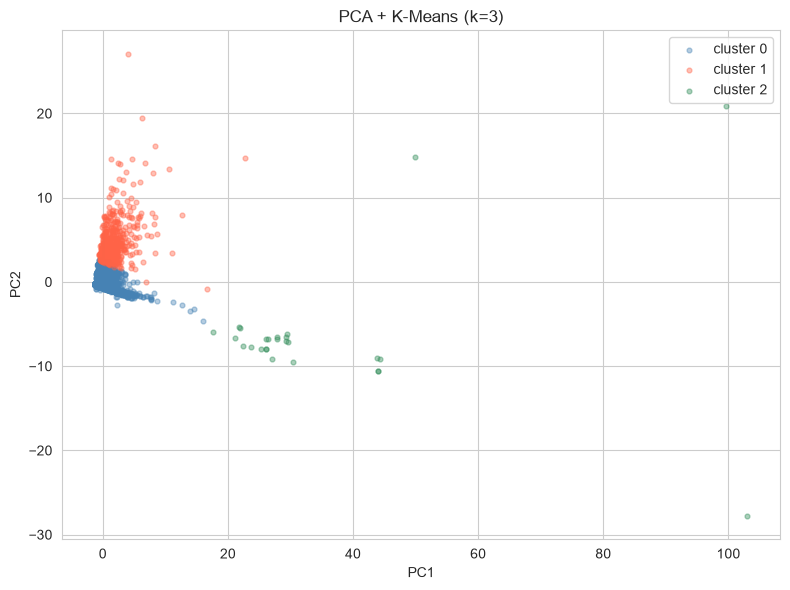

In [14]:
dfc = df[METRICAS].dropna().copy()
X = StandardScaler().fit_transform(dfc)
pca = PCA(n_components=4); comp = pca.fit_transform(X)
for i,v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}% (acum {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)')
km = KMeans(n_clusters=3, random_state=42, n_init=10)
lab = km.fit_predict(X)
fig, ax = plt.subplots(figsize=(8,6))
for k,c in zip(range(3), ['steelblue','tomato','seagreen']):
    m = lab==k; ax.scatter(comp[m,0], comp[m,1], s=12, alpha=0.4, color=c, label=f'cluster {k}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(); ax.set_title('PCA + K-Means (k=3)')
plt.tight_layout(); plt.savefig('pca_clusters.png', bbox_inches='tight'); plt.show()

## 10. Comparação entre repositórios

In [15]:
cols_repo = [c for c in ['LOC','WMC','CBO','RFC','McCC_avg','LCOM_norm'] if c in df.columns]
rs = df.groupby('repo')[cols_repo].mean().round(2); rs['n'] = df.groupby('repo').size()
rs = rs.sort_values('WMC', ascending=False); rs

,LOC,WMC,CBO,RFC,McCC_avg,LCOM_norm,n
repo,,,,,,,
adriandeleon/Editora,101.87,26.00,5.83,26.77,2.44,0.31,452
cloudempiere/com.cloudempiere.searchindex,69.86,16.28,4.76,14.20,2.04,0.52,50
pulumi/pulumi-java,74.94,11.88,5.52,4.14,1.10,0.55,8228
yksi7417/cross_asset_ems,56.32,11.46,5.93,13.24,1.43,0.33,616
nxmatic/rke2lab,59.49,10.13,5.33,9.63,1.28,0.43,763
apache/flink-agents,53.40,9.99,6.74,14.32,1.67,0.29,647
jbiscella/H-tchen-Mail,44.07,9.91,6.36,18.60,1.65,0.27,221
Kyu-seok/CodeBite,37.35,8.45,7.39,12.25,1.70,0.27,174
shossain786/utem-core,44.61,7.97,8.83,17.86,1.62,0.20,207


## 11. Síntese para o artigo

In [16]:
print('=== SÍNTESE ===')
print(f'Classes: {len(df)} | Repos: {df.repo.nunique()}')
print(f'Classes com bug data: {len(built)} | bugs totais: {int(built.Number_of_bugs.sum())}')
print()
print('Métricas (média / mediana / max):')
for c in METRICAS:
    s=df[c].dropna(); print(f'  {c:10s}: {s.mean():.2f} / {s.median():.0f} / {s.max():.0f}')
print()
print('Top correlações métrica×bugs:')
print(bug_corr.head(6).to_string())

=== SÍNTESE ===
Classes: 11459 | Repos: 10
Classes com bug data: 1771 | bugs totais: 527

Métricas (média / mediana / max):
  LOC       : 70.61 / 49 / 7445
  WMC       : 12.00 / 8 / 1830
  CBO       : 5.74 / 5 / 418
  RFC       : 7.23 / 2 / 1525
  DIT       : 1.37 / 1 / 74
  NOC       : 0.28 / 0 / 1436
  LCOM      : 152.60 / 10 / 327645
  LCOM_norm : 0.49 / 1 / 1
  NM        : 10.01 / 8 / 810
  NPM       : 8.38 / 6 / 810
  McCC_avg  : 1.24 / 1 / 18
  McCC_max  : 1.89 / 1 / 49

Top correlações métrica×bugs:
             rho        p  sig
Métrica                       
NPM        0.308  4.2e-40  ***
LCOM_norm  0.307  1.6e-39  ***
WMC        0.281  2.2e-33  ***
LOC        0.265  7.8e-30  ***
McCC_max   0.241  7.3e-23  ***
NM         0.235  1.2e-23  ***
